## 3.1
ID: 377

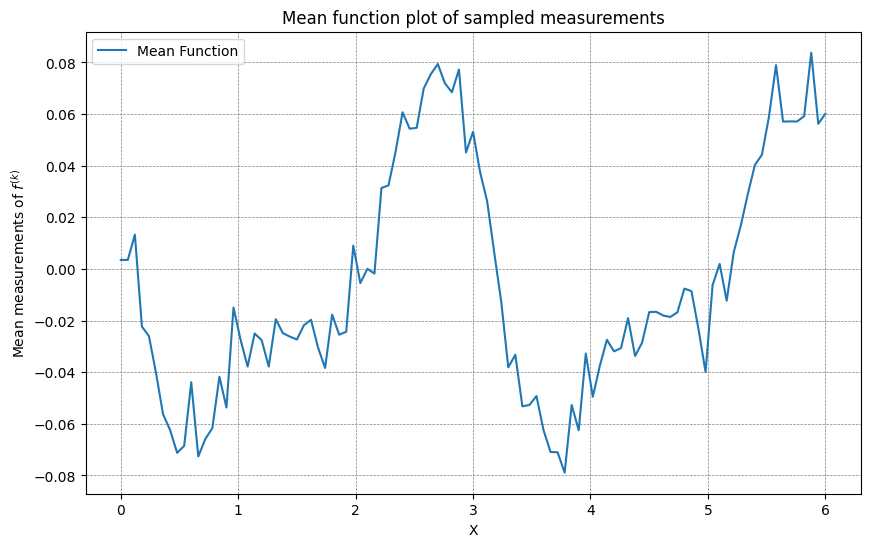

In [207]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("functions.npy")

mean_function = np.mean(data, axis=0)
delta = 0.06
X = np.arange(0, delta * len(mean_function), delta)

plt.figure(figsize=(10, 6))
plt.plot(X, mean_function, label="Mean Function")
plt.xlabel("X")
plt.ylabel("Mean measurements of $f^{(k)}$")
plt.title("Mean function plot of sampled measurements")
plt.grid(True)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## 3.2

Number of components that explain 95% of the variance: 5 at 0.979%


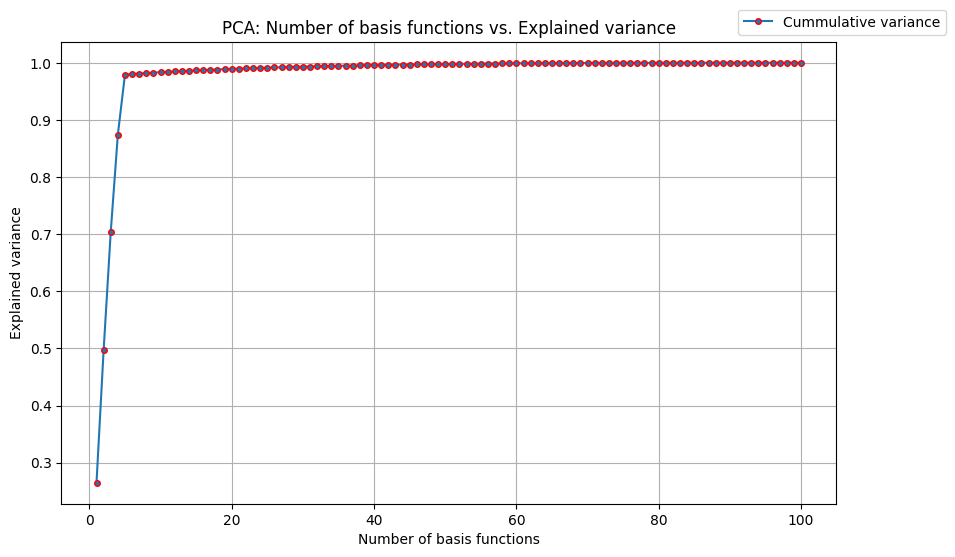

In [208]:
from sklearn.decomposition import PCA

# input whitening: zero mean and unit variance
data_centered = data - mean_function
data_whitened = data_centered / (np.std(data_centered, axis=0))

pca = PCA()
pca.fit(data_whitened)

# a)
cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
# find number of components to explain 95% of the variance
F = np.argmax(cumsum_variance >= 0.95) + 1
print(f'Number of components that explain 95% of the variance: {F} at {format(cumsum_variance[F-1], ".3f")}%')

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, marker='o', mec='red', ms=4, label="Cummulative variance")
plt.xlabel("Number of basis functions")
plt.ylabel("Explained variance")
plt.title("PCA: Number of basis functions vs. Explained variance")
plt.legend(loc="lower right", bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.show()

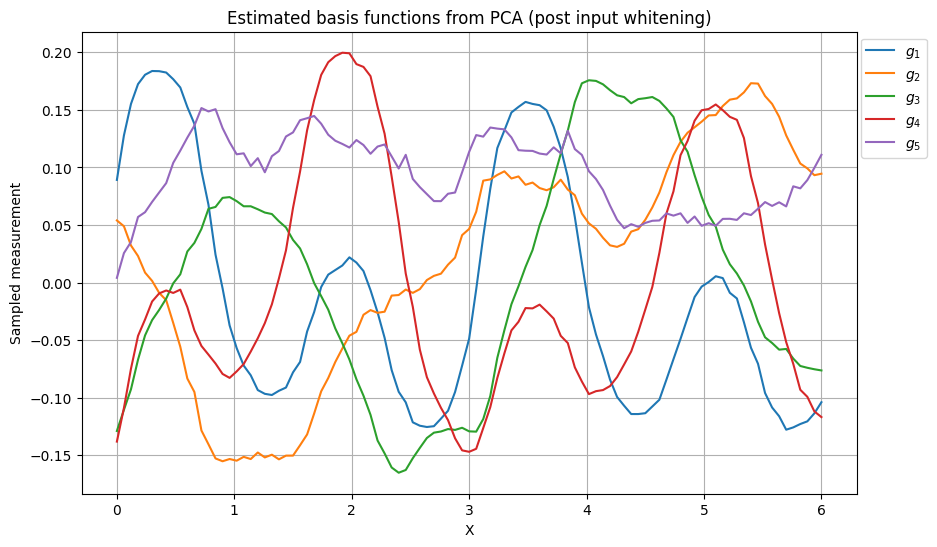

In [209]:
# b)
# extract first 5 basis functions
basis_functions = pca.components_[:F]

plt.figure(figsize=(10, 6))
X = np.arange(data.shape[1]) * 0.06
for i, basis_function in enumerate(basis_functions):
    plt.plot(X, basis_function, label=f"$g_{i+1}$")

plt.xlabel("X")
plt.ylabel("Sampled measurement")
plt.title("Estimated basis functions from PCA (post input whitening)")
plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))
plt.grid(True)
plt.show()


## 3.3

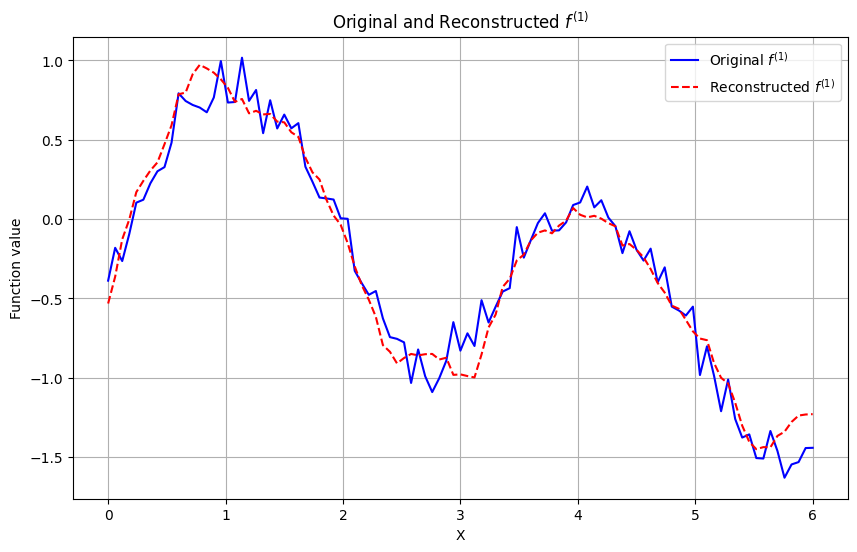

In [210]:
# the original function
f_1 = data[0]

# reshape the centered data into 2D for scikit-learn
f_1_centered = data_centered[0].reshape(1, -1)
# project the centered f_1 data points onto our 5 principle components
coefficients = pca.transform(f_1_centered)[0][:F]
# reconstruct f_1 by combining a_i dot g_i and adding the mean function
reconstructed_f_1 = np.dot(coefficients, basis_functions) + mean_function

plt.figure(figsize=(10, 6))
plt.plot(X, f_1, label="Original $f^{(1)}$", color='blue')
plt.plot(X, reconstructed_f_1, label="Reconstructed $f^{(1)}$", linestyle='--', color='red')
plt.xlabel("X")
plt.ylabel("Function value")
plt.title("Original and Reconstructed $f^{(1)}$")
plt.legend()
plt.grid(True)
plt.show()

## 3.4

In [211]:
# residuals
errors = f_1 - reconstructed_f_1

# estimate variance of the noise
variance = np.mean(errors**2)
print(variance)

0.018161573775302618
